# Evaluación Módulo 3: Aplicación de modelos VAR y ARDL para el pronóstico de series financieras

## Parte 1: Modelo Vectorial Autorregresivo VAR aplicado a precios de cierre de RYLD, TSLA, TM y GM

En este notebook se desarrolla la SEGUNDA parte de la evaluación del Módulo 3, enfocada en la aplicación de un modelo vectorial autorregresivo VAR sobre un conjunto de series financieras. Para ello, se utilizan los precios de cierre de los activos RYLD, TSLA, TM y GM en el periodo comprendido entre el 22 de abril de 2019 y el 31 de diciembre de 2022.

El objetivo es preparar las series, evaluar su comportamiento temporal, realizar las transformaciones necesarias para ajustar un modelo VAR, generar pronósticos y analizar el desempeño del modelo mediante métricas de error. Adicionalmente, se incluye un análisis de impulso-respuesta para interpretar la relación dinámica entre las variables del sistema.

### 1. Carga de librerías

In [1]:
# Instalación de yfinance en caso de que no esté disponible
# !pip install yfinance
#!pip install statsmodels

In [2]:
# Instalación de yfinance en caso de que no esté disponible
# !pip install yfinance

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR

from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### 2. descarga de datos

In [33]:
# Definición de activos y periodo de análisis
tickers = ["RYLD", "TSLA", "TM", "GM"]

fecha_inicio = "2019-04-22"
fecha_fin = "2022-12-31"

# Descarga de datos desde Yahoo Finance
datos = yf.download(
    tickers,
    start=fecha_inicio,
    end=fecha_fin,
    progress=False
)

# Selección de precios de cierre
precios_cierre = datos["Close"].copy()

# Reordenar columnas siguiendo el orden de los notebooks guía
precios_cierre = precios_cierre[["RYLD", "TSLA", "TM", "GM"]]

# Visualización inicial
precios_cierre.head()

Ticker,RYLD,TSLA,TM,GM
Date,,,,
2019-04-22,10.930377,17.516666,104.495285,36.404476
2019-04-23,11.001213,17.593332,105.151733,36.708618
2019-04-24,11.015204,17.243999,103.417992,36.607239
2019-04-25,10.989408,16.508667,103.678894,36.045040
2019-04-26,11.030951,15.676000,104.040794,36.570374


En esta sección se descargan desde Yahoo Finance los precios de cierre de los activos RYLD, TSLA, TM y GM para el periodo definido en la evaluación: del 22 de abril de 2019 al 31 de diciembre de 2022.

Estos precios de cierre serán la base para construir el conjunto de series financieras multivariadas requerido para aplicar el modelo VAR.

### 3. Revisión inicial de los datos

In [34]:
# Revisión de dimensiones
print("Dimensiones de la base:", precios_cierre.shape)

# Rango de fechas
print("\nRango de fechas:")
print("Fecha inicial:", precios_cierre.index.min())
print("Fecha final:", precios_cierre.index.max())

# Valores faltantes por activo
print("\nValores faltantes por activo:")
print(precios_cierre.isna().sum())

# Información general del DataFrame
print("\nInformación general:")
precios_cierre.info()

Dimensiones de la base: (933, 4)

Rango de fechas:
Fecha inicial: 2019-04-22 00:00:00
Fecha final: 2022-12-30 00:00:00

Valores faltantes por activo:
Ticker
RYLD    0
TSLA    0
TM      0
GM      0
dtype: int64

Información general:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 933 entries, 2019-04-22 to 2022-12-30
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RYLD    933 non-null    float64
 1   TSLA    933 non-null    float64
 2   TM      933 non-null    float64
 3   GM      933 non-null    float64
dtypes: float64(4)
memory usage: 36.4 KB


La base descargada contiene 933 observaciones diarias para los cuatro activos seleccionados: GM, RYLD, TM y TSLA. El periodo disponible va desde el 22 de abril de 2019 hasta el 30 de diciembre de 2022, lo cual coincide con el intervalo solicitado en la evaluación.

Adicionalmente, no se identificaron valores faltantes en ninguna de las series, por lo que no fue necesario aplicar imputaciones ni eliminar registros. Esto permite continuar con el análisis gráfico y posteriormente con la preparación de los datos para el modelo VAR.

### 4. Base de trabajo

In [35]:
df_precios = precios_cierre.copy()
df_precios.head()

Ticker,RYLD,TSLA,TM,GM
Date,,,,
2019-04-22,10.930377,17.516666,104.495285,36.404476
2019-04-23,11.001213,17.593332,105.151733,36.708618
2019-04-24,11.015204,17.243999,103.417992,36.607239
2019-04-25,10.989408,16.508667,103.678894,36.045040
2019-04-26,11.030951,15.676000,104.040794,36.570374


La base de trabajo conserva las cuatro series de precios de cierre y no presenta valores faltantes, por lo que se puede continuar con la visualización inicial de las series.

### 5. Visualización de las series en niveles

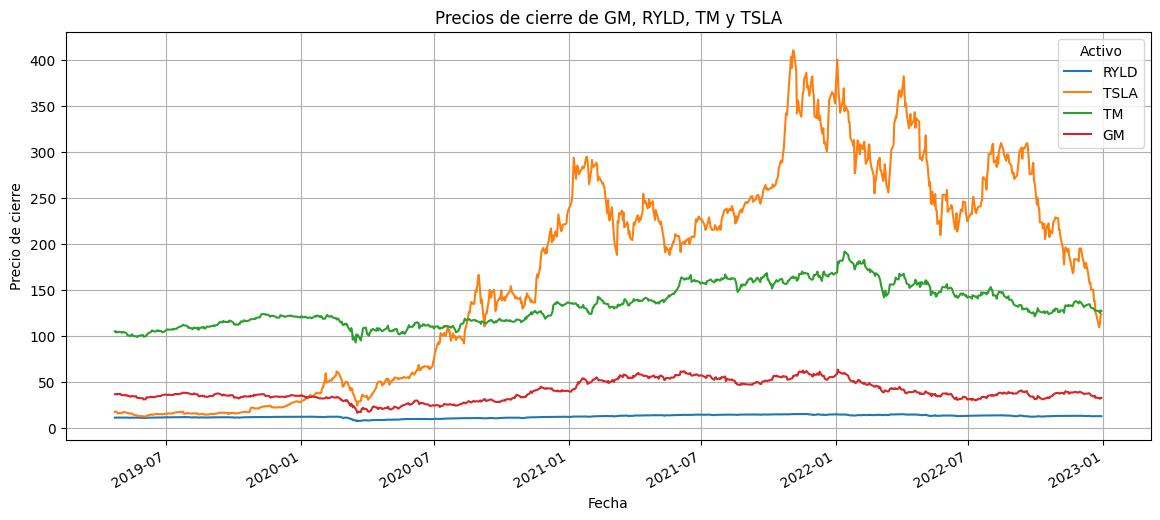

In [36]:
# Gráfico de precios de cierre
df_precios.plot(figsize=(14, 6))

plt.title("Precios de cierre de GM, RYLD, TM y TSLA")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend(title="Activo")
plt.show()

En la visualización se observa que las series presentan comportamientos diferentes en nivel. TSLA muestra la mayor volatilidad y un crecimiento fuerte hasta finales de 2021, seguido por una caída importante durante 2022. TM mantiene precios más altos que GM y RYLD, con una tendencia relativamente más estable, aunque también presenta variaciones durante el periodo. GM tiene movimientos moderados y RYLD permanece como la serie más estable en nivel.

En general, las series no parecen estacionarias en niveles, ya que presentan tendencias, cambios de escala y variaciones persistentes en el tiempo. Por esta razón, más adelante será necesario realizar pruebas formales de estacionariedad antes de ajustar el modelo VAR.

### 6. Visualización de series normalizadas

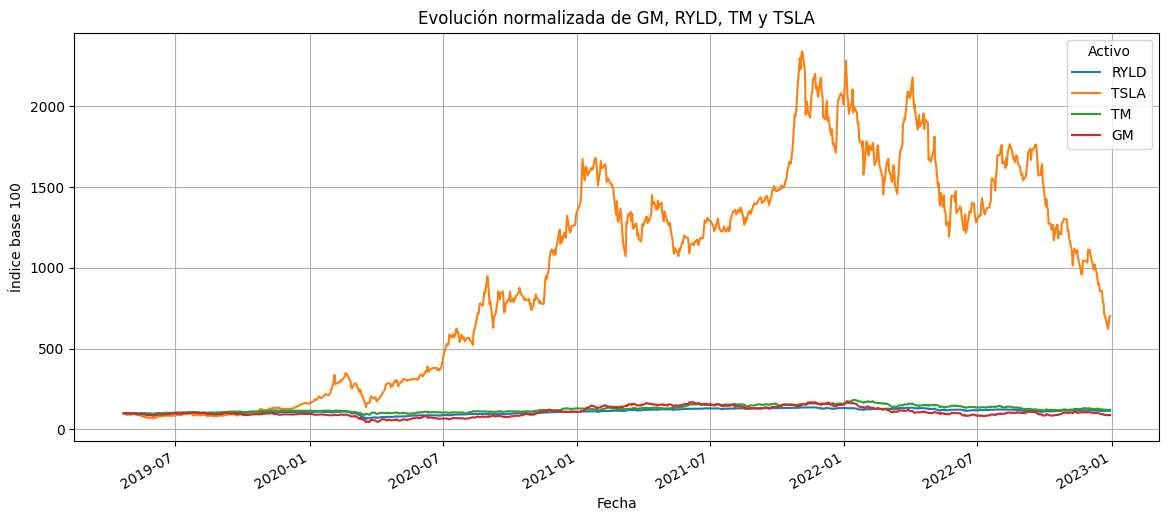

In [37]:
# Normalización de las series tomando como base el primer valor observado
df_normalizado = df_precios / df_precios.iloc[0] * 100

# Gráfico de series normalizadas
df_normalizado.plot(figsize=(14, 6))

plt.title("Evolución normalizada de GM, RYLD, TM y TSLA")
plt.xlabel("Fecha")
plt.ylabel("Índice base 100")
plt.legend(title="Activo")
plt.show()

La visualización normalizada permite comparar el crecimiento relativo de los activos tomando como base el primer valor observado. Se evidencia que TSLA tuvo el mayor crecimiento acumulado durante el periodo, alcanzando niveles muy superiores al resto de series, aunque también presentó una caída fuerte durante 2022. 

### 7. División entrenamiento y prueba

In [38]:
# Tamaño del conjunto de prueba: 5% de las observaciones
n_test = int(len(df_precios) * 0.05)

# División temporal
train = df_precios.iloc[:-n_test].copy()
test = df_precios.iloc[-n_test:].copy()

print("Total de observaciones:", len(df_precios))
print("Observaciones entrenamiento:", len(train))
print("Observaciones prueba:", len(test))

print("\nRango entrenamiento:")
print(train.index.min(), "a", train.index.max())

print("\nRango prueba:")
print(test.index.min(), "a", test.index.max())

Total de observaciones: 933
Observaciones entrenamiento: 887
Observaciones prueba: 46

Rango entrenamiento:
2019-04-22 00:00:00 a 2022-10-25 00:00:00

Rango prueba:
2022-10-26 00:00:00 a 2022-12-30 00:00:00


La división se realizó respetando el orden temporal de las series. El conjunto de entrenamiento contiene el 95% inicial de las observaciones y el conjunto de prueba conserva el 5% final.

### 8. Visualización de la partición entrenamiento-prueba

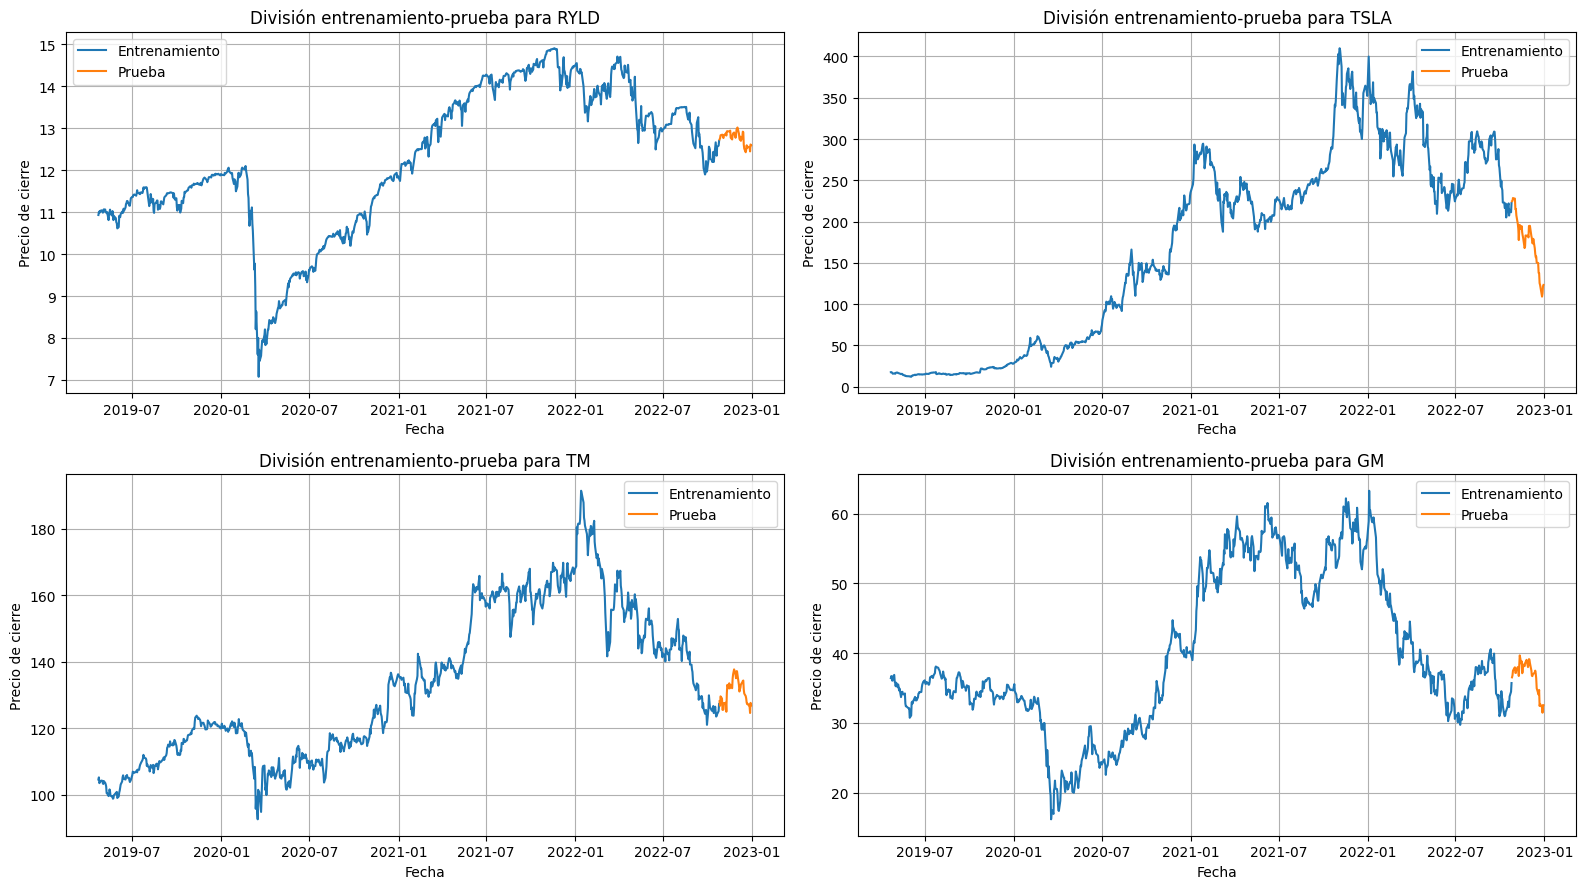

In [39]:
# Gráfico de entrenamiento y prueba en una matriz 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

axes = axes.flatten()

for i, columna in enumerate(df_precios.columns):
    axes[i].plot(train.index, train[columna], label="Entrenamiento")
    axes[i].plot(test.index, test[columna], label="Prueba")
    axes[i].set_title(f"División entrenamiento-prueba para {columna}")
    axes[i].set_xlabel("Fecha")
    axes[i].set_ylabel("Precio de cierre")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

La partición entrenamiento-prueba permite observar que el conjunto de prueba corresponde al tramo final de cada serie, respetando la estructura temporal de los datos. En este periodo final se observa una tendencia descendente especialmente marcada en TSLA, mientras que GM, TM y RYLD presentan movimientos más moderados. 

### 9. Prueba de estacionariedad en niveles

In [40]:
# Función para aplicar la prueba ADF a cada serie
def prueba_adf(series, nombre):
    resultado = adfuller(series)
    
    return {
        "Serie": nombre,
        "ADF Statistic": resultado[0],
        "p-value": resultado[1],
        "Rezagos usados": resultado[2],
        "Observaciones": resultado[3],
        "Conclusión": "Estacionaria" if resultado[1] < 0.05 else "No estacionaria"
    }

# Aplicación de la prueba ADF a las series en niveles del conjunto de entrenamiento
resultados_adf_niveles = []

for columna in train.columns:
    resultados_adf_niveles.append(prueba_adf(train[columna], columna))

df_adf_niveles = pd.DataFrame(resultados_adf_niveles)

df_adf_niveles

,Serie,ADF Statistic,p-value,Rezagos usados,Observaciones,Conclusión
0,RYLD,-1.485917,0.540466,9,877,No estacionaria
1,TSLA,-1.435813,0.564992,10,876,No estacionaria
2,TM,-1.643619,0.460371,0,886,No estacionaria
3,GM,-1.344353,0.608645,10,876,No estacionaria


De acuerdo con la prueba ADF aplicada sobre las series en niveles, ninguna de las cuatro series resulta estacionaria al 5% de significancia. Esto se observa porque los valores p son superiores a 0.05 en GM, RYLD, TM y TSLA.

Por tanto, no es conveniente ajustar directamente el modelo VAR sobre las series en niveles, ya que podrían generarse relaciones espurias. 

### 10. Diferenciación de las series

In [41]:
# Primera diferencia de las series de entrenamiento
train_diff = train.diff().dropna()

# Visualización inicial de las series diferenciadas
train_diff.head()

Ticker,RYLD,TSLA,TM,GM
Date,,,,
2019-04-23,0.070836,0.076666,0.656448,0.304142
2019-04-24,0.013991,-0.349333,-1.733742,-0.101379
2019-04-25,-0.025796,-0.735332,0.260902,-0.562199
2019-04-26,0.041543,-0.832667,0.361900,0.525333
2019-04-29,0.010931,0.422000,0.159912,0.304142


Se aplicó la primera diferencia a las series de entrenamiento con el objetivo de remover tendencias y estabilizar el comportamiento temporal.

A partir de este punto, el modelo VAR se ajustará sobre estas series diferenciadas únicamente si las pruebas de estacionariedad confirman que la transformación fue suficiente.

## 11. Prueba de estacionariedad sobre series diferenciadas

In [42]:
# Aplicación de la prueba ADF a las series diferenciadas
resultados_adf_diff = []

for columna in train_diff.columns:
    resultados_adf_diff.append(prueba_adf(train_diff[columna], columna))

df_adf_diff = pd.DataFrame(resultados_adf_diff)

df_adf_diff

,Serie,ADF Statistic,p-value,Rezagos usados,Observaciones,Conclusión
0,RYLD,-8.641238,5.418905e-14,8,877,Estacionaria
1,TSLA,-9.031584,5.426765e-15,9,876,Estacionaria
2,TM,-8.722274,3.360457e-14,14,871,Estacionaria
3,GM,-9.721662,9.508036e-17,9,876,Estacionaria


Después de aplicar la primera diferencia, las cuatro series resultan estacionarias según la prueba ADF, ya que todos los valores p son menores a 0.05

Esto indica que la transformación fue suficiente para estabilizar las series y permite continuar con la estimación del modelo VAR sobre las series diferenciadas

### 12. Visualización de las series diferenciadas

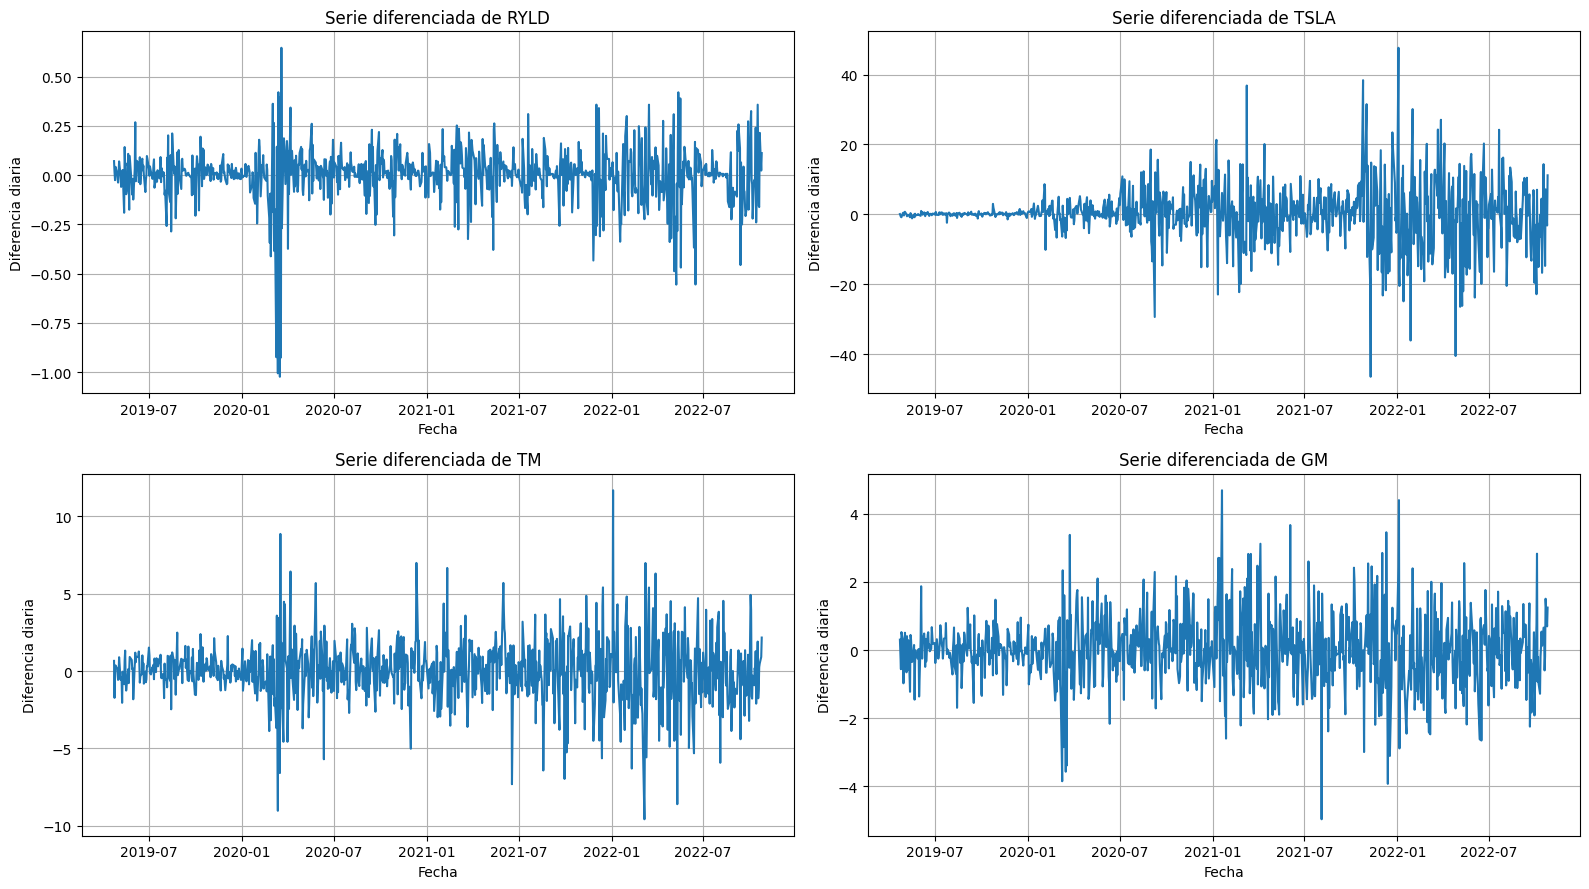

In [43]:
# Gráfico de series diferenciadas en una matriz 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

axes = axes.flatten()

for i, columna in enumerate(train_diff.columns):
    axes[i].plot(train_diff.index, train_diff[columna])
    axes[i].set_title(f"Serie diferenciada de {columna}")
    axes[i].set_xlabel("Fecha")
    axes[i].set_ylabel("Diferencia diaria")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Las series diferenciadas muestran un comportamiento más estable alrededor de cero, lo cual es consistente con los resultados de la prueba ADF. Sin embargo, también se observan episodios de alta volatilidad, especialmente en TSLA y, en menor medida, en TM y GM. RYLD presenta variaciones más pequeñas, aunque con algunos cambios fuertes alrededor de 2020. 

En general, la diferenciación permite trabajar con series estacionarias, pero se mantiene la presencia de choques importantes asociados a movimientos bruscos del mercado financiero.

### 13. Selección del número de rezagos del modelo VAR

In [44]:
# Ajuste inicial del objeto VAR sobre las series diferenciadas
modelo_var = VAR(train_diff)

# Selección del número de rezagos usando criterios de información
seleccion_rezagos = modelo_var.select_order(maxlags=15)

seleccion_rezagos.summary()

/opt/anaconda3/envs/pronosticos_meta/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,0.8722,0.8942*,2.392,0.8806*
1,0.8576,0.9672,2.358,0.8996
2,0.8164*,1.014,2.262*,0.8918
3,0.8418,1.127,2.321,0.9508
4,0.8502,1.223,2.340,0.9927
5,0.8703,1.330,2.388,1.046
6,0.8922,1.440,2.441,1.102
7,0.8886,1.524,2.432,1.132
8,0.8940,1.617,2.445,1.171
9,0.8888,1.699,2.433,1.199


De acuerdo con los criterios de información, AIC y FPE sugieren utilizar 2 rezagos, mientras que BIC y HQIC recomiendan 0 rezagos. 

el objetivo es estimar un modelo VAR que capture relaciones dinámicas entre las series, se selecciona un modelo VAR con 2 rezagos. Esta decisión permite conservar una estructura autorregresiva sin aumentar excesivamente la complejidad del modelo.

### 14. Ajuste del modelo VAR

In [45]:
# Definición del número de rezagos seleccionado
lag_optimo = 2

# Ajuste del modelo VAR
modelo_var_ajustado = modelo_var.fit(lag_optimo)

# Resumen del modelo ajustado
modelo_var_ajustado.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 21, May, 2026
Time:                     23:17:57
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   0.961409
Nobs:                     884.000    HQIC:                  0.841062
Log likelihood:          -5320.19    FPE:                    2.15237
AIC:                     0.766567    Det(Omega_mle):         2.06690
--------------------------------------------------------------------
Results for equation RYLD
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.001942         0.004611            0.421           0.674
L1.RYLD        -0.131119         0.044462           -2.949           0.003
L1.TSLA         0.000140         0.000632            0.221           0.825
L1.TM     

Al estimar el modelo VAR(2) sobre las series diferenciadas, se observa que no todas las variables responden de la misma manera a la información pasada del sistema. 

En el caso de RYLD, los resultados muestran que sus propios rezagos tienen peso dentro del modelo, especialmente el primer y segundo rezago. También aparecen efectos significativos del segundo rezago de TSLA y GM, lo que indica que los movimientos previos de estos activos pueden estar relacionados con los cambios actuales de RYLD.

Para TSLA, los coeficientes no presentan significancia estadística al 5%. Esto sugiere que, dentro de esta especificación, sus variaciones no quedan explicadas de forma clara por los rezagos considerados de las demás series. Este resultado es coherente con el comportamiento observado en las gráficas, donde TSLA presentó una volatilidad mucho más marcada y posiblemente influenciada por factores externos al sistema.

En la ecuación de TM, el efecto más relevante proviene del primer rezago de RYLD. Los demás rezagos no muestran evidencia estadística fuerte, por lo que la relación dinámica de TM con el resto de activos parece ser más limitada en este modelo.

Para GM, se identifican efectos significativos asociados al segundo rezago de RYLD, TSLA y TM. Esto indica que GM sí recoge información pasada de varias series del sistema, especialmente en el segundo periodo de rezago.

En conjunto, el modelo muestra algunas relaciones temporales entre los activos, aunque no todas las ecuaciones tienen el mismo nivel de explicación. La matriz de correlación de residuales también deja ver correlaciones moderadas entre algunos activos, lo que sugiere que todavía existen movimientos comunes que el modelo no captura completamente.

### 15. Verificación de estabilidad del modelo VAR

In [46]:
# Verificación de estabilidad del modelo VAR ajustado
es_estable = modelo_var_ajustado.is_stable(verbose=True)

print("¿El modelo VAR es estable?:", es_estable)

Eigenvalues of VAR(1) rep
0.5354221058153182
0.29255620629615703
0.29255620629615703
0.17736144141053145
0.37749915416958246
0.29186902333844833
0.29186902333844833
0.13157956472020527
¿El modelo VAR es estable?: True


El modelo VAR(2) cumple la condición de estabilidad, ya que los valores propios se encuentran dentro del rango requerido y la función retorna `True`. Esto permite continuar con el análisis impulso-respuesta, dado que las respuestas dinámicas del sistema pueden interpretarse de manera adecuada.

### 16. Análisis impulso-respuesta

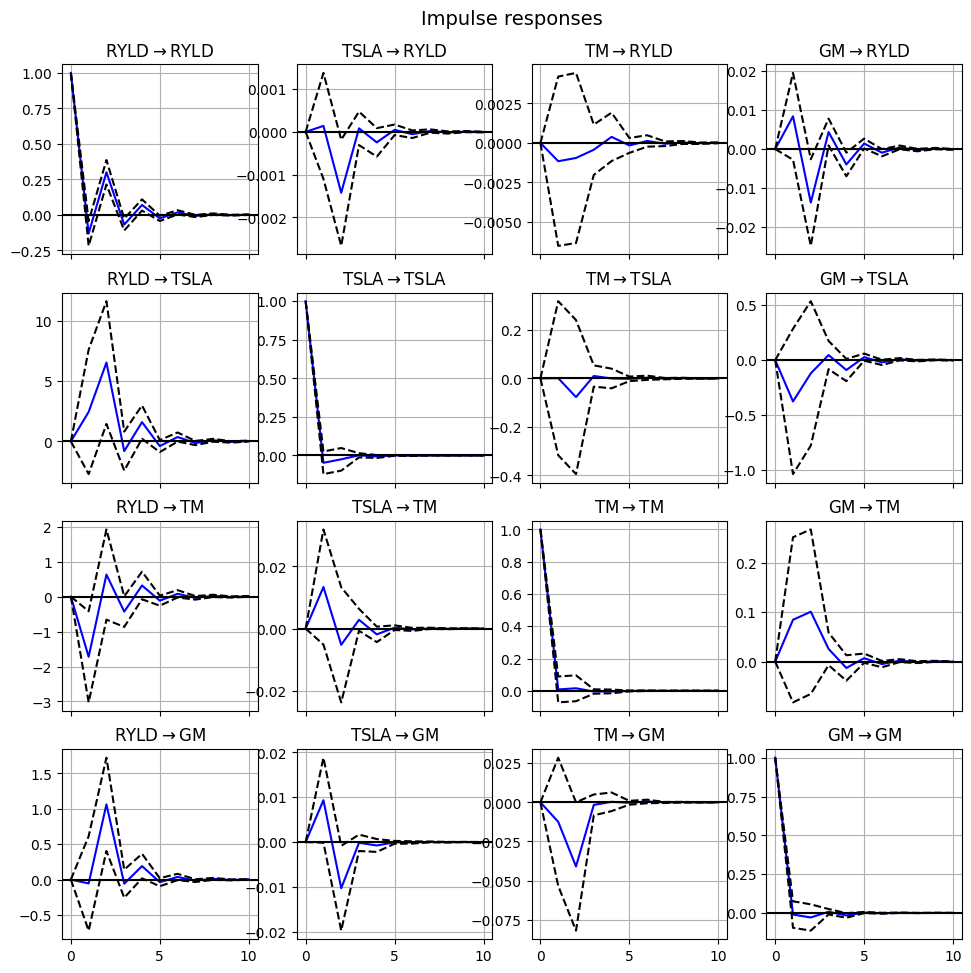

In [47]:
# Cálculo de funciones impulso-respuesta para 10 periodos
irf = modelo_var_ajustado.irf(10)

# Visualización general del análisis impulso-respuesta
irf.plot(orth=False)

plt.show()

El análisis impulso-respuesta permite observar cómo reaccionan las series ante choques en cada uno de los activos del sistema. En general, las respuestas más fuertes se concentran en los primeros periodos y luego tienden a desaparecer rápidamente, lo cual es consistente con un modelo estable.

Se observa que los choques propios de cada activo tienen un impacto inicial alto sobre la misma serie, especialmente en RYLD, TSLA, TM y GM. Sin embargo, estos efectos pierden fuerza después de pocos periodos.

También se identifican algunas respuestas cruzadas entre activos. Por ejemplo, choques en RYLD generan movimientos visibles sobre TSLA, TM y GM, mientras que los efectos de TSLA, TM y GM sobre las demás variables tienden a ser más pequeños y de corta duración. Esto sugiere que existen relaciones dinámicas entre las series, aunque no todas tienen la misma intensidad.

En conjunto, el análisis muestra que los impactos del sistema son principalmente transitorios: los choques afectan las series durante los primeros días, pero luego las respuestas se estabilizan alrededor de cero.

### 17. Pronóstico sobre el conjunto de prueba

In [48]:
# Número de pasos a pronosticar: tamaño del conjunto de prueba
n_forecast = len(test)

# Últimos valores necesarios para iniciar el pronóstico
input_forecast = train_diff.values[-lag_optimo:]

# Pronóstico en diferencias
forecast_diff = modelo_var_ajustado.forecast(
    y=input_forecast,
    steps=n_forecast
)

# Convertir el pronóstico a DataFrame
forecast_diff_df = pd.DataFrame(
    forecast_diff,
    index=test.index,
    columns=train_diff.columns
)

forecast_diff_df.head()

Ticker,RYLD,TSLA,TM,GM
Date,,,,
2022-10-26,-0.001531,-0.439899,0.230700,0.056069
2022-10-27,-0.000280,0.360932,0.197466,-0.122749
2022-10-28,0.000060,0.232124,0.036044,-0.007567
2022-10-31,0.002582,0.216801,0.016380,-0.008651
2022-11-01,0.001278,0.223473,0.023911,-0.003285


El pronóstico generado por el VAR se encuentra en diferencias, porque el modelo fue estimado sobre las series transformadas para lograr estacionariedad. Por esta razón, antes de evaluar el desempeño del modelo, es necesario recuperar los valores en nivel y así compararlos directamente con los precios observados del conjunto de prueba.

## 18. Reconstrucción del pronóstico en niveles

In [49]:
# Último valor observado en el conjunto de entrenamiento
ultimo_valor_train = train.iloc[-1]

# Reconstrucción del pronóstico en niveles
forecast_niveles = forecast_diff_df.cumsum() + ultimo_valor_train

# Visualización inicial del pronóstico reconstruido
forecast_niveles.head()

Ticker,RYLD,TSLA,TM,GM
Date,,,,
2022-10-26,12.691397,221.980099,127.493365,35.761494
2022-10-27,12.691117,222.341031,127.690830,35.638746
2022-10-28,12.691177,222.573155,127.726874,35.631179
2022-10-31,12.693759,222.789955,127.743254,35.622528
2022-11-01,12.695037,223.013428,127.767166,35.619243


### 19. Comparación entre valores reales y pronosticados

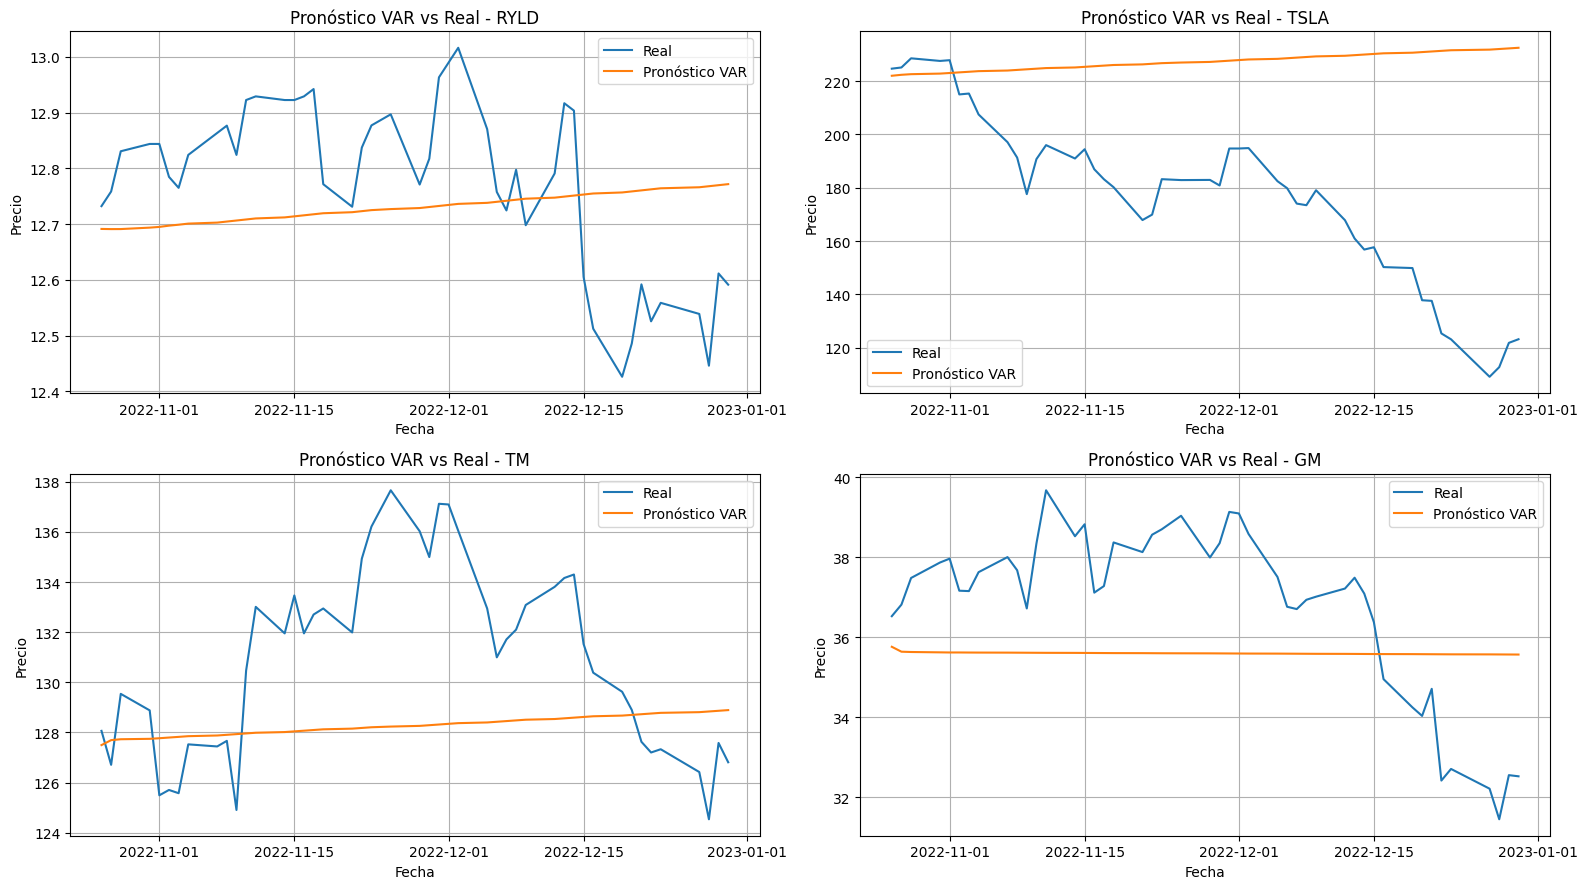

In [50]:
# Comparación gráfica entre valores reales y pronosticados en el conjunto de prueba
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

axes = axes.flatten()

for i, columna in enumerate(test.columns):
    axes[i].plot(test.index, test[columna], label="Real")
    axes[i].plot(forecast_niveles.index, forecast_niveles[columna], label="Pronóstico VAR")
    axes[i].set_title(f"Pronóstico VAR vs Real - {columna}")
    axes[i].set_xlabel("Fecha")
    axes[i].set_ylabel("Precio")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

En la comparación entre valores reales y pronosticados se observa que el modelo VAR genera trayectorias bastante suavizadas para los cuatro activos. Esto indica que el modelo logra proyectar una dirección general estable, pero no captura adecuadamente los cambios bruscos presentes en el conjunto de prueba.

El caso más evidente es TSLA, donde el precio real cae de forma marcada durante el periodo de evaluación, mientras que el pronóstico VAR mantiene una trayectoria levemente creciente. En TM también se observa una diferencia importante, ya que el valor real presenta una subida inicial y una posterior caída, mientras que el pronóstico permanece casi plano. Para GM y RYLD el modelo tampoco logra anticipar completamente los movimientos finales de la serie.

En general, el VAR muestra limitaciones para capturar la alta volatilidad del periodo de prueba, especialmente cuando los activos presentan cambios repentinos de tendencia.

### 20. Métricas de error del modelo VAR

In [52]:
# Función para calcular MAPE
def calcular_mape(y_real, y_pred):
    return np.mean(np.abs((y_real - y_pred) / y_real)) * 100

# Cálculo de métricas por activo
metricas_var = []

for columna in test.columns:
    y_real = test[columna]
    y_pred = forecast_niveles[columna]
    
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = calcular_mape(y_real, y_pred)
    
    metricas_var.append({
        "Activo": columna,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

df_metricas_var = pd.DataFrame(metricas_var)

df_metricas_var

,Activo,MAE,RMSE,MAPE (%)
0,RYLD,0.153872,0.174299,1.206131
1,TSLA,51.357709,60.940437,33.982829
2,TM,3.657086,4.447908,2.752253
3,GM,2.212530,2.395981,6.038640


Las métricas de error muestran que el desempeño del modelo VAR no fue homogéneo entre los activos. El mejor resultado se observa en RYLD, con un MAPE cercano al 1.21%, seguido por TM con un MAPE de 2.75%. Esto indica que para estas dos series el modelo logró aproximarse mejor a los valores reales del periodo de prueba.

En el caso de GM, el error fue mayor, aunque todavía se mantiene en un nivel moderado. Por el contrario, TSLA presentó el peor desempeño, con un MAPE cercano al 34%. Este resultado confirma lo observado en la gráfica anterior: el modelo VAR no logró capturar la caída fuerte de TSLA durante el periodo de prueba.

En general, el VAR funciona mejor para series con movimientos más estables, pero presenta dificultades cuando el activo tiene cambios abruptos o alta volatilidad.

### 21. Resumen general de métricas del VAR

In [53]:
# Promedio de métricas del modelo VAR
resumen_var = pd.DataFrame({
    "Modelo": ["VAR(2)"],
    "MAE promedio": [df_metricas_var["MAE"].mean()],
    "RMSE promedio": [df_metricas_var["RMSE"].mean()],
    "MAPE promedio (%)": [df_metricas_var["MAPE (%)"].mean()]
})

resumen_var

,Modelo,MAE promedio,RMSE promedio,MAPE promedio (%)
0,VAR(2),14.345299,16.989656,10.994963


El resumen general del modelo VAR(2) muestra un MAPE promedio cercano al 10.99%. Sin embargo, este valor está influenciado principalmente por el alto error obtenido en TSLA. Aunque el modelo tuvo buen desempeño en RYLD y TM, su capacidad predictiva disminuyó frente a activos con movimientos más volátiles o cambios fuertes de tendencia durante el periodo de prueba.

### 22. Pronóstico de 10 días hacia adelante con VAR

In [56]:
# Diferenciación de toda la base disponible
df_diff_completo = df_precios.diff().dropna()

# Ajuste del modelo VAR final usando toda la información disponible
modelo_var_final = VAR(df_diff_completo)
modelo_var_final_ajustado = modelo_var_final.fit(lag_optimo)

# Número de días a pronosticar hacia adelante
n_futuro = 10

# Últimos valores diferenciados disponibles
input_futuro = df_diff_completo.values[-lag_optimo:]

# Pronóstico futuro en diferencias
forecast_futuro_diff = modelo_var_final_ajustado.forecast(
    y=input_futuro,
    steps=n_futuro
)

# Crear fechas futuras usando días hábiles
fechas_futuras = pd.bdate_range(
    start=df_precios.index[-1] + pd.Timedelta(days=1),
    periods=n_futuro
)

# Convertir a DataFrame
forecast_futuro_diff_df = pd.DataFrame(
    forecast_futuro_diff,
    index=fechas_futuras,
    columns=df_diff_completo.columns
)

# Reconstrucción del pronóstico futuro en niveles
ultimo_valor_observado = df_precios.iloc[-1]

forecast_futuro_var = forecast_futuro_diff_df.cumsum() + ultimo_valor_observado

forecast_futuro_var

/opt/anaconda3/envs/pronosticos_meta/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Ticker,RYLD,TSLA,TM,GM
2023-01-02,12.613382,123.722694,127.040055,32.469570
2023-01-03,12.605389,123.818671,127.006295,32.468154
2023-01-04,12.613600,124.013499,127.046251,32.472067
2023-01-05,12.611997,124.081647,127.059382,32.461077
2023-01-06,12.615567,124.229116,127.091697,32.461055
2023-01-09,12.616321,124.325928,127.113070,32.454491
2023-01-10,12.618510,124.448959,127.140538,32.450935
2023-01-11,12.619942,124.557937,127.164767,32.445839
2023-01-12,12.621765,124.674010,127.190640,32.441504
2023-01-13,12.623382,124.786354,127.215657,32.436769


El pronóstico de 10 días hacia adelante muestra trayectorias suaves para los cuatro activos. Esta característica es coherente con el comportamiento observado anteriormente en el VAR, ya que el modelo tiende a proyectar cambios graduales y no movimientos bruscos. Por esta razón, el pronóstico debe interpretarse como una aproximación basada en la dinámica histórica de las series, no como una predicción exacta del comportamiento futuro del mercado.

### 23. Visualización del pronóstico futuro VAR

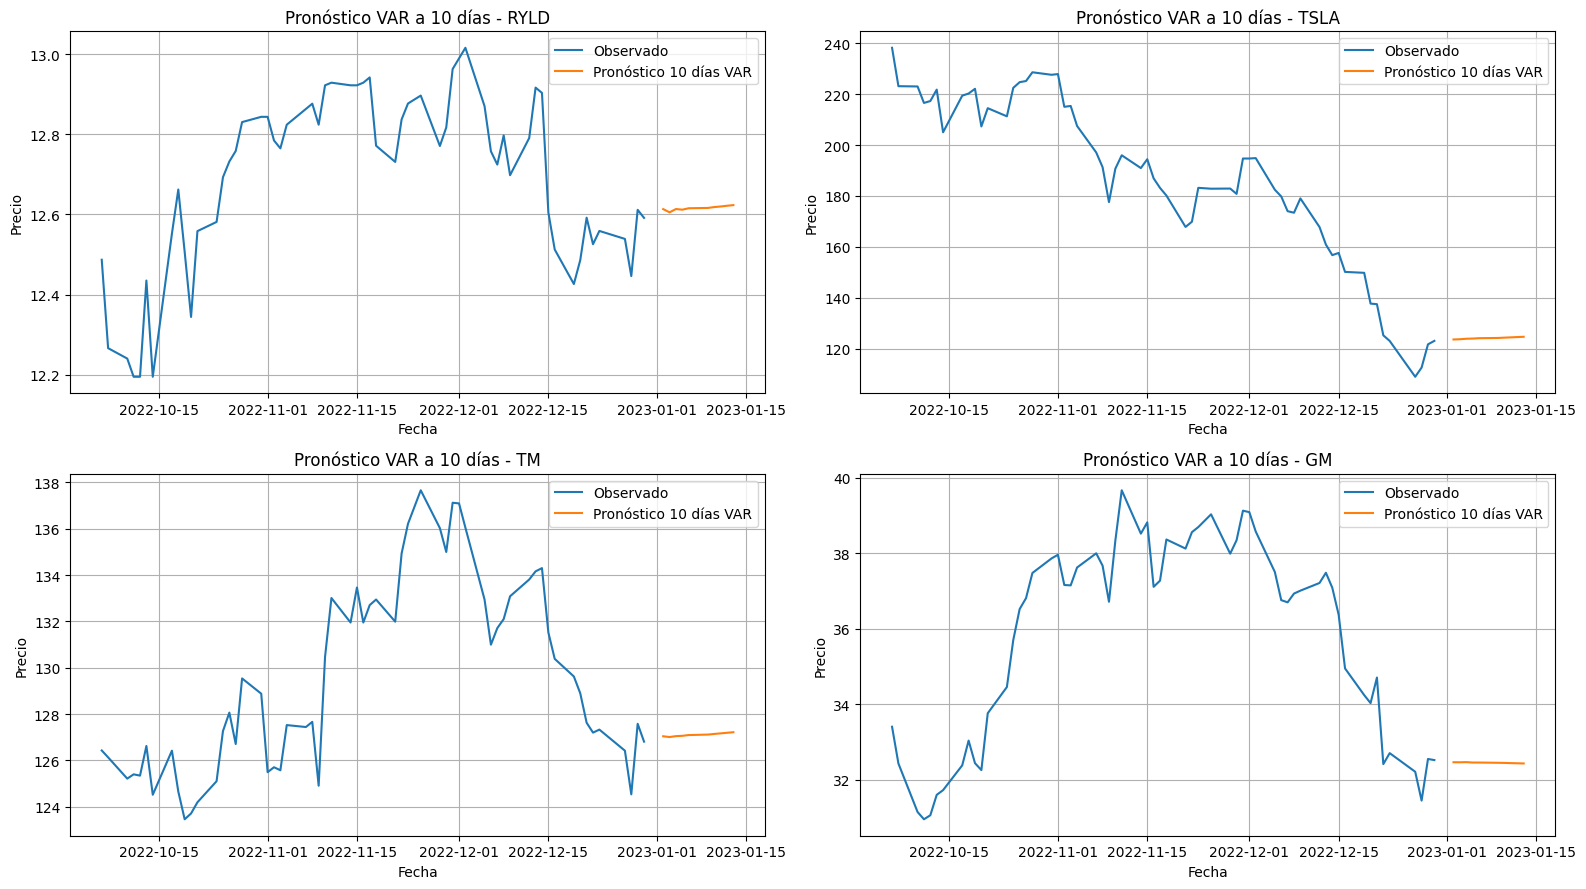

In [57]:
# Visualización del pronóstico futuro junto con los últimos datos observados
ultimos_datos = df_precios.tail(60)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

axes = axes.flatten()

for i, columna in enumerate(df_precios.columns):
    axes[i].plot(ultimos_datos.index, ultimos_datos[columna], label="Observado")
    axes[i].plot(forecast_futuro_var.index, forecast_futuro_var[columna], label="Pronóstico 10 días VAR")
    axes[i].set_title(f"Pronóstico VAR a 10 días - {columna}")
    axes[i].set_xlabel("Fecha")
    axes[i].set_ylabel("Precio")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

El pronóstico futuro de 10 días mantiene una trayectoria suavizada para los cuatro activos. En RYLD, TM y GM se observa una proyección casi estable, con ligeros cambios frente al último valor observado. Para TSLA también se proyecta una recuperación leve, aunque sin capturar movimientos abruptos.

Este comportamiento es consistente con lo observado en la evaluación sobre el conjunto de prueba: el modelo VAR tiende a generar pronósticos moderados y estables, por lo que puede ser útil para representar la dinámica promedio de las series, pero tiene limitaciones para anticipar caídas fuertes o cambios repentinos de tendencia.

### 24. Conclusión parcial del modelo VAR

El modelo VAR(2) permitió analizar las relaciones dinámicas entre los activos RYLD, TSLA, TM y GM a partir de sus series diferenciadas. Antes de estimar el modelo, fue necesario aplicar una primera diferencia, ya que las pruebas ADF mostraron que las series en niveles no eran estacionarias.

Los resultados muestran que el VAR captura algunas relaciones temporales entre los activos, especialmente en las ecuaciones de RYLD, TM y GM. Además, el modelo cumple la condición de estabilidad, lo que permitió realizar el análisis impulso-respuesta y observar que los choques entre variables tienden a desaparecer después de pocos periodos.

En términos predictivos, el desempeño fue desigual. El modelo presentó mejores resultados en RYLD y TM, mientras que tuvo mayores dificultades para TSLA, debido a la fuerte volatilidad y caída observada en el periodo de prueba. En general, el VAR ofrece una aproximación útil para modelar relaciones conjuntas entre series financieras, pero sus pronósticos tienden a ser suavizados y pueden quedarse cortos ante cambios bruscos del mercado.

## Parte 2: Modelo ARLD

In [ ]:
El pronóstico futuro de 10 días mantiene una trayectoria suavizada para los cuatro activos. En RYLD, TM y GM se observa una proyección casi estable, con ligeros cambios frente al último valor observado. Para TSLA también se proyecta una recuperación leve, aunque sin capturar movimientos abruptos.

Este comportamiento es consistente con lo observado en la evaluación sobre el conjunto de prueba: el modelo VAR tiende a generar pronósticos moderados y estables, por lo que puede ser útil para representar la dinámica promedio de las series, pero tiene limitaciones para anticipar caídas fuertes o cambios repentinos de tendencia.

### 1. Preparación de variables para ARDL

In [58]:
# Importar herramientas para ARDL
from statsmodels.tsa.ardl import ARDL, ardl_select_order

# Definición de variable dependiente y variables explicativas
y_train = train["RYLD"]
X_train = train[["TSLA", "TM", "GM"]]

y_test = test["RYLD"]
X_test = test[["TSLA", "TM", "GM"]]

print("Variable dependiente entrenamiento:", y_train.shape)
print("Variables explicativas entrenamiento:", X_train.shape)
print("Variable dependiente prueba:", y_test.shape)
print("Variables explicativas prueba:", X_test.shape)

Variable dependiente entrenamiento: (887,)
Variables explicativas entrenamiento: (887, 3)
Variable dependiente prueba: (46,)
Variables explicativas prueba: (46, 3)


### 2. Selección automática de rezagos del modelo ARDL

In [62]:
# Variable dependiente
y_train = train["RYLD"]

# Variables explicativas
X_train = train[["GM", "TM", "TSLA"]]

# Selección automática de rezagos ARDL
seleccion_ardl = ardl_select_order(
    endog=y_train,
    exog=X_train,
    maxlag=5,
    maxorder=5,
    ic="aic",
    trend="c"
)


/opt/anaconda3/envs/pronosticos_meta/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/pronosticos_meta/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [63]:
# Revisión de la estructura seleccionada
print("Rezagos seleccionados para la variable dependiente:")
print(seleccion_ardl.ar_lags)

print("\nRezagos seleccionados para las variables explicativas:")
print(seleccion_ardl.dl_lags)

Rezagos seleccionados para la variable dependiente:
[1, 2, 3]

Rezagos seleccionados para las variables explicativas:
{'GM': [0, 1, 2, 3], 'TM': [0, 1], 'TSLA': [0, 1]}


### 3. Ajuste del modelo ARDL

In [65]:
# Ajuste del modelo seleccionado
modelo_ardl_ajustado = seleccion_ardl.model.fit()

# Resumen del modelo
print(modelo_ardl_ajustado.summary())

                              ARDL Model Results                              
Dep. Variable:                   RYLD   No. Observations:                  887
Model:               ARDL(3, 3, 1, 1)   Log Likelihood                 772.299
Method:               Conditional MLE   S.D. of innovations              0.101
Date:                Thu, 21 May 2026   AIC                          -1518.597
Time:                        23:45:31   BIC                          -1456.399
Sample:                             3   HQIC                         -1494.817
                                  887                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0284      0.039      0.737      0.461      -0.047       0.104
RYLD.L1        0.8684      0.031     28.406      0.000       0.808       0.928
RYLD.L2        0.3019      0.039      7.773      0.0

La selección automática por AIC eligió un modelo ARDL(3, 3, 1, 1). Esto significa que el modelo utiliza tres rezagos de RYLD, tres rezagos de GM, un rezago de TM y un rezago de TSLA. Esta estructura permite incorporar tanto la memoria propia de RYLD como la información rezagada de los demás activos.

En el resumen del modelo se observa que varios coeficientes son estadísticamente significativos al 5%. Los rezagos de RYLD resultan relevantes, lo que indica que el comportamiento pasado de la propia serie aporta información para explicar su valor actual. También se identifican efectos significativos de GM, TM y TSLA, tanto en sus valores contemporáneos como en algunos rezagos.

En general, el modelo ARDL muestra una relación dinámica clara entre RYLD y las variables explicativas seleccionadas. A diferencia del VAR, este enfoque se concentra en explicar una variable objetivo específica, lo cual resulta útil para evaluar directamente el pronóstico de RYLD.

### 4. Pronóstico ARDL sobre el conjunto de prueba

In [69]:
# Pronóstico ARDL sobre el conjunto de prueba usando predict
forecast_ardl = modelo_ardl_ajustado.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog_oos=X_test
)

# Convertir a Serie con el índice del conjunto de prueba
forecast_ardl = pd.Series(
    forecast_ardl.values,
    index=y_test.index,
    name="Pronóstico ARDL"
)

forecast_ardl.head()

/opt/anaconda3/envs/pronosticos_meta/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Date
2022-10-26    21.563797
2022-10-27    22.019994
2022-10-28    21.534407
2022-10-31    21.630309
2022-11-01    21.428379
Name: Pronóstico ARDL, dtype: float64

### 5. Comparación entre RYLD real y pronóstico ARDL

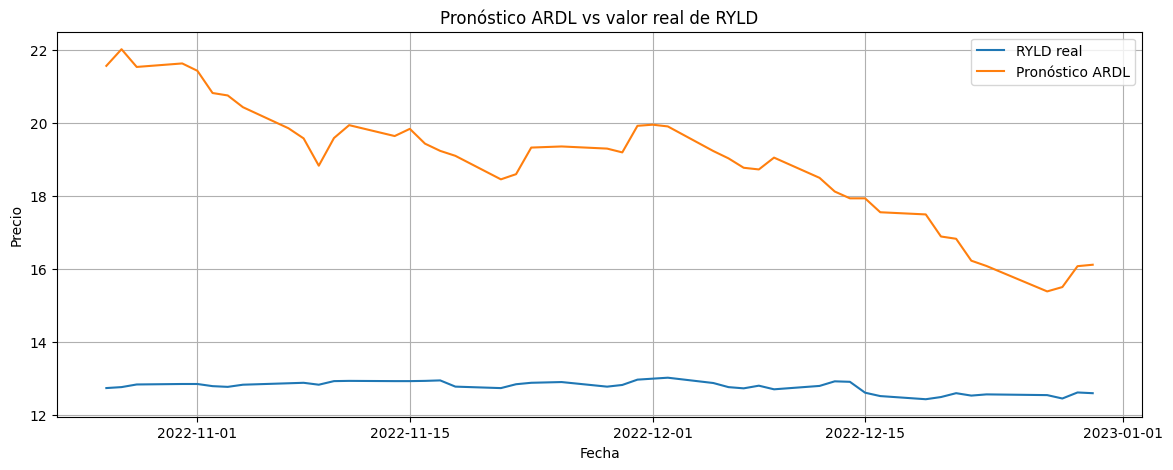

In [70]:
plt.figure(figsize=(14, 5))

plt.plot(y_test.index, y_test, label="RYLD real")
plt.plot(forecast_ardl.index, forecast_ardl, label="Pronóstico ARDL")

plt.title("Pronóstico ARDL vs valor real de RYLD")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True)
plt.show()

La comparación visual muestra que el modelo ARDL no logra aproximarse bien al nivel real de RYLD durante el periodo de prueba. Aunque el pronóstico presenta una tendencia descendente, se mantiene claramente por encima de los valores observados. Esto indica que, bajo esta especificación, el modelo captura cierta dirección general, pero falla en el nivel del pronóstico.

### 6. Métricas de error del modelo ARDL

In [71]:
# Cálculo de métricas para ARDL
mae_ardl = mean_absolute_error(y_test, forecast_ardl)
rmse_ardl = np.sqrt(mean_squared_error(y_test, forecast_ardl))
mape_ardl = calcular_mape(y_test, forecast_ardl)

metricas_ardl = pd.DataFrame({
    "Modelo": ["ARDL"],
    "MAE": [mae_ardl],
    "RMSE": [rmse_ardl],
    "MAPE (%)": [mape_ardl]
})

metricas_ardl

,Modelo,MAE,RMSE,MAPE (%)
0,ARDL,6.153395,6.346323,48.090718


Las métricas del modelo ARDL confirman el bajo ajuste observado en la gráfica. El MAPE es cercano al 48.09%, lo que indica un error porcentual alto para el pronóstico de RYLD. Aunque el modelo logra reflejar cierta tendencia descendente, no aproxima correctamente el nivel real de la serie durante el periodo de prueba.

### 7. Comparación de desempeño entre VAR y ARDL para RYLD

In [73]:
# Extraer métricas del modelo VAR para RYLD
metricas_var_ryld = df_metricas_var[df_metricas_var["Activo"] == "RYLD"].copy()

# Construir tabla comparativa
comparacion_ryld = pd.DataFrame({
    "Modelo": ["VAR(2)", "ARDL"],
    "MAE": [
        metricas_var_ryld["MAE"].values[0],
        mae_ardl
    ],
    "RMSE": [
        metricas_var_ryld["RMSE"].values[0],
        rmse_ardl
    ],
    "MAPE (%)": [
        metricas_var_ryld["MAPE (%)"].values[0],
        mape_ardl
    ]
})

comparacion_ryld

,Modelo,MAE,RMSE,MAPE (%)
0,VAR(2),0.153872,0.174299,1.206131
1,ARDL,6.153395,6.346323,48.090718


La comparación directa entre VAR(2) y ARDL para RYLD muestra una diferencia clara en el desempeño predictivo. El modelo VAR(2) obtuvo errores mucho menores en todas las métricas evaluadas, con un MAPE cercano al 1.21%, mientras que el modelo ARDL presentó un MAPE aproximado de 48.09%.

De acuerdo con estos resultados, el modelo VAR(2) es el más adecuado para pronosticar RYLD en este ejercicio. Aunque el ARDL permite explicar RYLD a partir de otras variables, en este caso no logró aproximar correctamente el nivel de la serie durante el periodo de prueba.

### 8. Conclusión final de la comparación de modelos

A partir de los resultados obtenidos, el modelo VAR(2) presenta el mejor desempeño para el pronóstico de RYLD frente al modelo ARDL. La selección se justifica principalmente por las métricas de error, ya que el VAR obtuvo valores considerablemente menores de MAE, RMSE y MAPE.

El VAR permitió modelar las relaciones dinámicas entre las cuatro series financieras y, aunque sus pronósticos tienden a ser suavizados, logró ajustarse mucho mejor al comportamiento real de RYLD durante el periodo de prueba. Por su parte, el modelo ARDL incorporó rezagos de RYLD y de los activos GM, TM y TSLA, pero produjo una sobreestimación importante del valor real de RYLD.

En conclusión, para este conjunto de datos y bajo las especificaciones utilizadas, el modelo VAR(2) se selecciona como el modelo con mejor desempeño predictivo. No obstante, ambos modelos presentan limitaciones frente a cambios abruptos del mercado financiero, por lo que sus pronósticos deben interpretarse como aproximaciones basadas en patrones históricos y no como predicciones exactas del precio futuro.